# Solver Demo

Choosing the right integrator matters: the wrong solver can introduce false
structure, miss events, or simply give the wrong answer.

This notebook collects examples drawn from three models that each stress a
different solver concern:

- **EBM0D** — smooth continuous ODE; illustrates tolerance effects and the
  cost of fixed-step vs adaptive integration
- **G24** — piecewise-smooth discrete-event model; shows how timestep size
  drives artificial harmonics
- **Lorenz96 two-scale** — stiff fast-slow system; demonstrates that adaptive
  solvers corrupt the accumulated history and `rk4` is required

A summary table at the end gives guidance for each model class.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import paleobeasts as pb
from paleobeasts.signal_models.ebm import EBM0D, albedo_func
from paleobeasts.signal_models.g24 import Model3, calc_f
from paleobeasts.signal_models.lorenz import Lorenz96


## EBM0D: smooth continuous ODE

`EBM0D` is a single-variable ODE with no fast processes and a smooth right-hand
side — the ideal case for an adaptive solver.

### RK45 tolerances

PaleoBeasts uses tighter-than-scipy-default tolerances
(`rtol=1e-8, atol=1e-10`) to suppress ghost structure in slow steady-state
tails.  With scipy defaults the equilibrium temperature can appear to drift by
a few mK even after the model has converged.

Run the same integration with both tolerance levels and compare.


In [38]:
model = EBM0D()

# Package-default tight tolerances
out_tight = model.integrate(t_span=(0, 500), y0=[255.0], method='RK45')

# Scipy-default relaxed tolerances (pass empty kwargs to bypass PB defaults)
out_scipy = model.integrate(t_span=(0, 500), y0=[255.0], method='RK45', kwargs={})

T_tight = out_tight.state_variables['T']
T_scipy = out_scipy.state_variables['T']


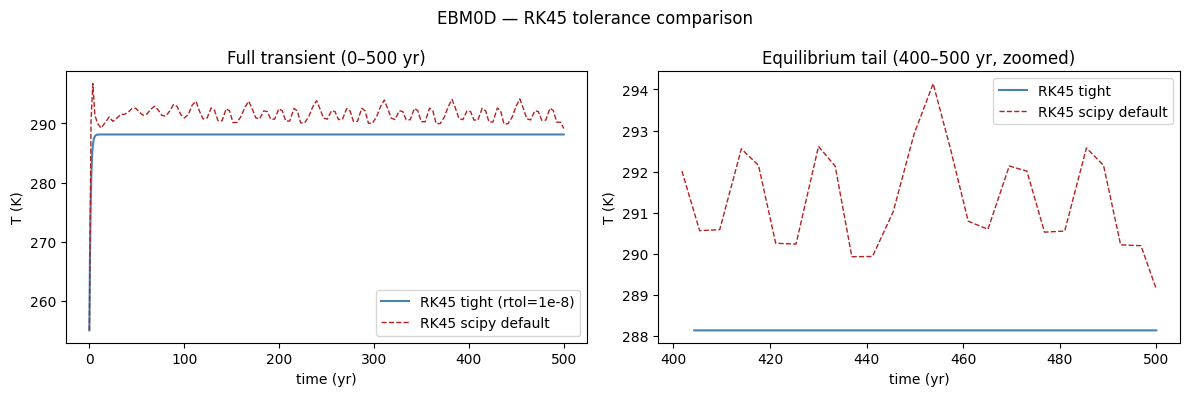

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full transient
axes[0].plot(out_tight.time, T_tight, color='steelblue', lw=1.5,
             label='RK45 tight (rtol=1e-8)')
axes[0].plot(out_scipy.time, T_scipy, color='firebrick', lw=1, ls='--',
             label='RK45 scipy default')
axes[0].set_xlabel('time (yr)'); axes[0].set_ylabel('T (K)')
axes[0].set_title('Full transient (0–500 yr)'); axes[0].legend()

# Zoom on the equilibrium tail — separate masks per run (adaptive solver step counts differ)
mask_tight = out_tight.time > 400
mask_scipy = out_scipy.time > 400
axes[1].plot(out_tight.time[mask_tight], T_tight[mask_tight], color='steelblue', lw=1.5,
             label='RK45 tight')
axes[1].plot(out_scipy.time[mask_scipy], T_scipy[mask_scipy], color='firebrick', lw=1, ls='--',
             label='RK45 scipy default')
axes[1].set_xlabel('time (yr)'); axes[1].set_ylabel('T (K)')
axes[1].set_title('Equilibrium tail (400–500 yr, zoomed)'); axes[1].legend()

fig.suptitle('EBM0D — RK45 tolerance comparison')
plt.tight_layout(); plt.show()


**Figure.** Left: both runs trace the same transient — tolerance has no visible
effect during the fast warm-up.  Right (zoomed): with scipy defaults (rtol=1e-3,
atol=1e-6) the equilibrium tail shows a few mK of drift that disappears with
tight tolerances.  For publication-quality figures or bifurcation analyses that
compare equilibria, use the package defaults or tighter.


### Fixed-step solver: Euler

`euler` takes a fixed `dt` and never adapts.  It is slower per unit of
accuracy than RK45 but has no overhead from step-size control — useful when
the right-hand side is cheap or when a specific temporal resolution is required.


In [40]:
model_e = EBM0D()
out_euler = model_e.integrate(t_span=(0, 500), y0=[255.0], method='euler', dt=1.0)
T_euler   = out_euler.state_variables['T']
print(f'Euler T_eq = {T_euler[-1]:.4f} K   RK45 T_eq = {T_tight[-1]:.4f} K')


Euler T_eq = 288.1313 K   RK45 T_eq = 288.1313 K


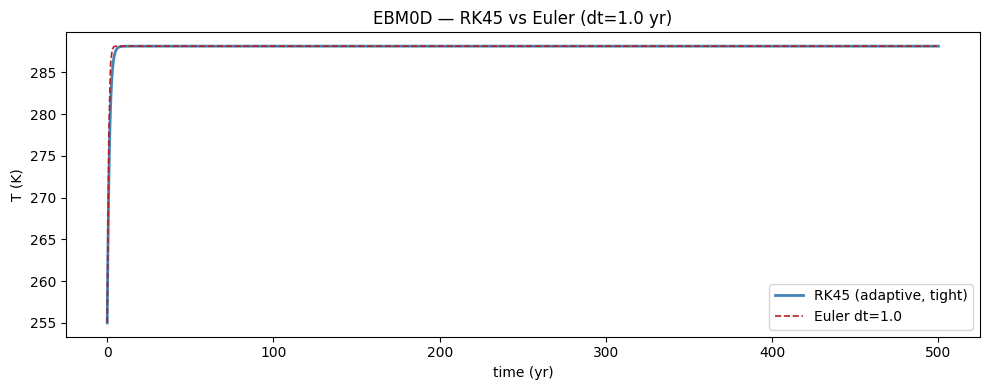

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(out_tight.time, T_tight, color='steelblue', lw=2,   label='RK45 (adaptive, tight)')
ax.plot(out_euler.time, T_euler, color='firebrick', lw=1.2, ls='--', label='Euler dt=1.0')
ax.set_xlabel('time (yr)'); ax.set_ylabel('T (K)')
ax.set_title('EBM0D — RK45 vs Euler (dt=1.0 yr)')
ax.legend(); plt.tight_layout(); plt.show()


**Figure.** Both methods converge to the same equilibrium temperature.
Euler overshoots the fast early transient slightly and is marginally slower
due to the fixed small step, but produces the correct long-run behaviour.
RK45 adapts its step size to track the transient efficiently and is the
preferred choice for smooth ODEs like EBM0D.


### Spurious structure in the transient

With the ice-albedo feedback active (`albedo=albedo_func`) the EBM0D has two
attractors separated by an unstable branch near 260–290 K.  Loose solver
tolerances don't change the long-run equilibrium, but they can make the
*transient* look wrong: the solver takes large, inaccurate steps that produce
oscillations or apparent excursions toward the opposite branch — structure that
does not exist in the true solution.  A reader looking only at the transient
could mistake a numerical artefact for genuine metastability or bifurcation
behaviour.


In [42]:
ICs = [230, 245,251, 258,265, 268,272, 278, 288, 295, 300]   # K
colors = plt.cm.coolwarm(np.linspace(0, 1, len(ICs)))

runs_tight, runs_scipy = [], []
m = EBM0D(albedo=albedo_func)
for T0 in ICs:
    runs_tight.append((T0, m.integrate(t_span=(0, 500), y0=[T0], method='RK45')))
    runs_scipy.append((T0, m.integrate(t_span=(0, 500), y0=[T0], method='RK45', kwargs={})))


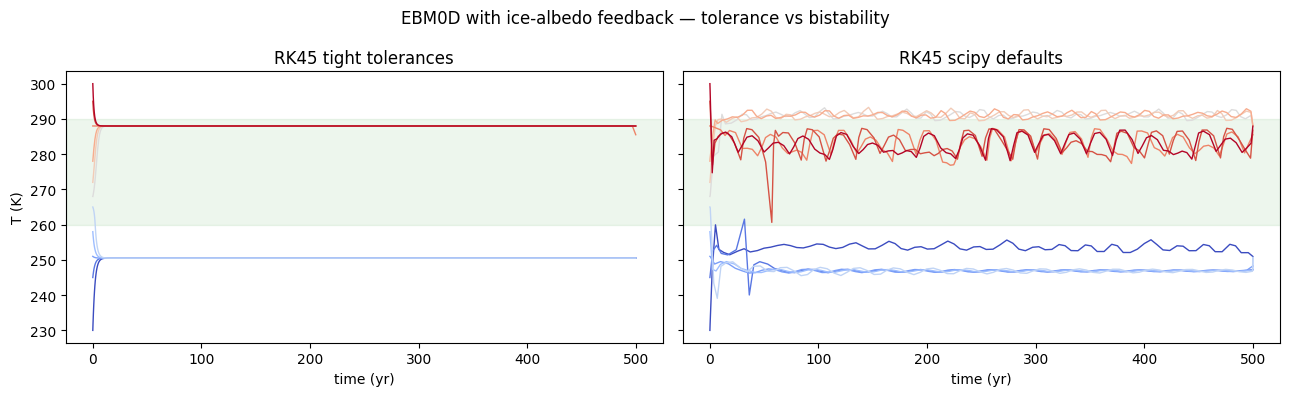

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ik, (title, run_set) in enumerate([
        ('RK45 tight tolerances', runs_tight),
        ('RK45 scipy defaults',   runs_scipy)]):
    for (T0, out), c in zip(run_set, colors):
        axs[ik].plot(out.time, out.state_variables['T'], color=c, lw=1)
    axs[ik].axhspan(260, 290, alpha=0.07, color='green')
    axs[ik].set_xlabel('time (yr)'); axs[ik].set_title(title)
axs[0].set_ylabel('T (K)')
fig.suptitle('EBM0D with ice-albedo feedback — tolerance vs bistability')
plt.tight_layout(); plt.show()


**Figure.** All trajectories reach the same long-run equilibria regardless of
tolerance (warm or cold branch, matching tight tolerances), so the solver
configuration has no effect on the *answer*.  The transient is a different
matter: with scipy default tolerances (right panel) some trajectories show
noisy, irregular paths — including brief apparent excursions toward the
opposite branch — that are absent under tight tolerances (left panel).  These
are solver artefacts, not physics.  The shaded band marks the unstable
transition zone where the true solution changes direction rapidly; this is
exactly where a large step is most likely to mis-evaluate the derivative and
introduce spurious structure.


## G24: discrete-event ODE

`Model3` from Ganopolski (2024) switches between two regime functions at
discrete thresholds — the right-hand side is continuous but contains rapid
jumps in `k` (the glaciation/deglaciation state).  Adaptive solvers can
mis-step across these events and introduce artificial sub-harmonic structure
in the ice-volume record.

**Fixed-step solvers (Euler, rk4)** must be used.  The paper uses ~6.5 kyr.
This section shows: (1) how Euler and rk4 compare across timesteps, and
(2) what happens when you pass RK45 to this model.


In [44]:
g24_forcing = pb.core.Forcing(calc_f, params={'A': 25, 'eps': 0.5})

f1, f2 = -16.0, 16.0
vc     = 1.4
t1, t2 = 30.0, 10.0
A, eps = 25, 0.5
T_SPAN = (-2000, 0)   # kyr
ZOOM   = (-1000, 0)

delta_ts = [2.0, 4.0, 6.5, 10.0]

runs_euler = {}
for dt in delta_ts:
    m = Model3(vc=vc, f1=f1, f2=f2, t1=t1, t2=t2)
    m.register_forcing('insolation', g24_forcing)
    out = m.integrate(t_span=T_SPAN, y0=[0.0, 1], method='euler', dt=dt)
    runs_euler[dt] = out
    n_term = int(np.sum(np.diff(out.state_variables['k']) > 0))
    print(f'dt={dt:5.1f} kyr  {n_term} terminations  '
          f'(mean {abs(T_SPAN[0])/max(n_term,1):.0f} kyr cycle)')


dt=  2.0 kyr  20 terminations  (mean 100 kyr cycle)
dt=  4.0 kyr  20 terminations  (mean 100 kyr cycle)
dt=  6.5 kyr  19 terminations  (mean 105 kyr cycle)
dt= 10.0 kyr  18 terminations  (mean 111 kyr cycle)


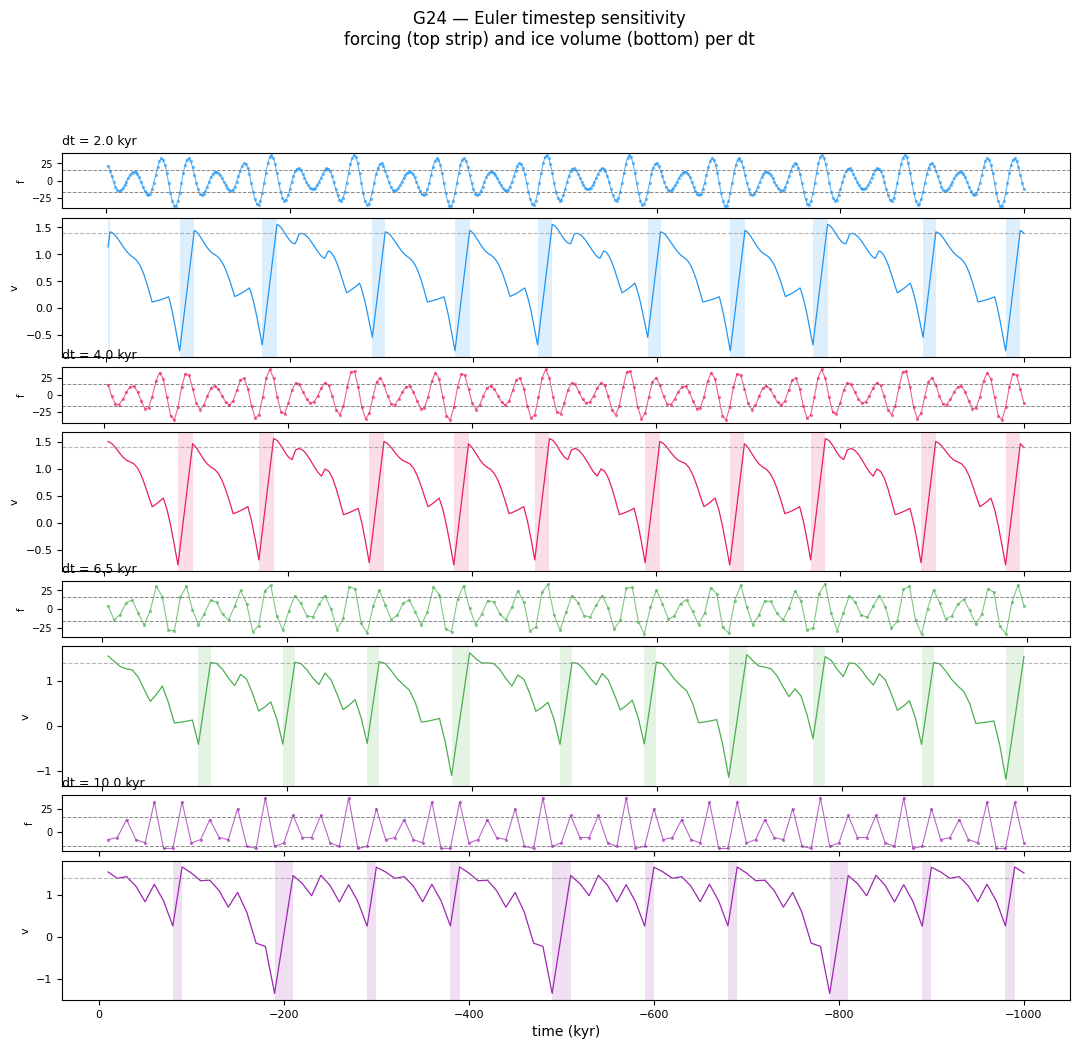

In [45]:
colours = ['#2196F3', '#E91E63', '#4CAF50', '#9C27B0']
n = len(delta_ts)

fig = plt.figure(figsize=(13, 11))
# 2 rows per dt: [forcing strip, ice volume] with height ratio 1:2.5
hr = [h for _ in range(n) for h in (1, 2.5)]
gs = fig.add_gridspec(2 * n, 1, hspace=0.1, height_ratios=hr)

for idx, (dt, col) in enumerate(zip(delta_ts, colours)):
    ax_f = fig.add_subplot(gs[2 * idx])
    ax_v = fig.add_subplot(gs[2 * idx + 1], sharex=ax_f)

    out = runs_euler[dt]
    t = out.time
    v = out.state_variables['v']
    k = out.state_variables['k']
    mask = (t >= ZOOM[0]) & (t <= ZOOM[1])
    tm, vm, km = t[mask], v[mask], k[mask]

    # Forcing sampled at this dt's timesteps
    fm = calc_f(tm, A=A, eps=eps)

    # ── Forcing strip ──────────────────────────────────────────────────────
    ax_f.plot(tm, fm, lw=0.8, color=col, alpha=0.7)
    ax_f.scatter(tm, fm, s=2, color=col, alpha=0.5, zorder=3)
    ax_f.axhline(f1, ls='--', color='#888', lw=0.7)   # inception threshold
    ax_f.axhline(f2, ls='--', color='#888', lw=0.7)   # deglaciation threshold
    ax_f.set_ylabel('f', fontsize=7)
    ax_f.tick_params(labelbottom=False, labelsize=7)
    ax_f.set_title(f'dt = {dt} kyr', loc='left', fontsize=9)

    # ── Ice volume ─────────────────────────────────────────────────────────
    in_k2 = False
    for j in range(len(tm)):
        if km[j] == 2 and not in_k2:
            x0 = tm[j]; in_k2 = True
        elif km[j] != 2 and in_k2:
            ax_v.axvspan(x0, tm[j], alpha=0.15, color=col, lw=0)
            in_k2 = False
    if in_k2:
        ax_v.axvspan(x0, tm[-1], alpha=0.15, color=col, lw=0)

    ax_v.plot(tm, vm, lw=0.9, color=col)
    ax_v.axhline(vc, ls='--', color='#888', lw=0.8, alpha=0.6)
    ax_v.set_ylabel('v', fontsize=8)
    ax_v.tick_params(labelsize=8)
    if idx < n - 1:
        ax_v.tick_params(labelbottom=False)

    ax_f.invert_xaxis()

ax_v.set_xlabel('time (kyr)')
fig.suptitle('G24 — Euler timestep sensitivity\nforcing (top strip) and ice volume (bottom) per dt',
             y=1.01)
plt.show()


**Figure.** Each dt group shows: (top) the orbital forcing $f(t)$ sampled at
that timestep — markers indicate the actual evaluation points — with dashed
lines at the inception ($f_1$) and deglaciation ($f_2$) thresholds; (bottom)
the resulting ice volume, with deglaciation phases (k = 2) shaded and $v_c$
dashed.

At **dt = 2–4 kyr** the forcing is well-resolved: the ~21 kyr precession and
~41 kyr obliquity beats are both captured, and the ice volume shows canonical
~100 kyr saw-tooth cycles.  At **dt = 6.5 kyr** the forcing is marginally
resolved; the ~23 kyr precession cycle begins to alias but the 100 kyr rhythm
persists.  At **dt = 10 kyr** long gaps between forcing evaluations allow
threshold crossings to be stepped over entirely — the model enters or exits
a glaciation at the wrong time, producing irregular or shortened cycles.


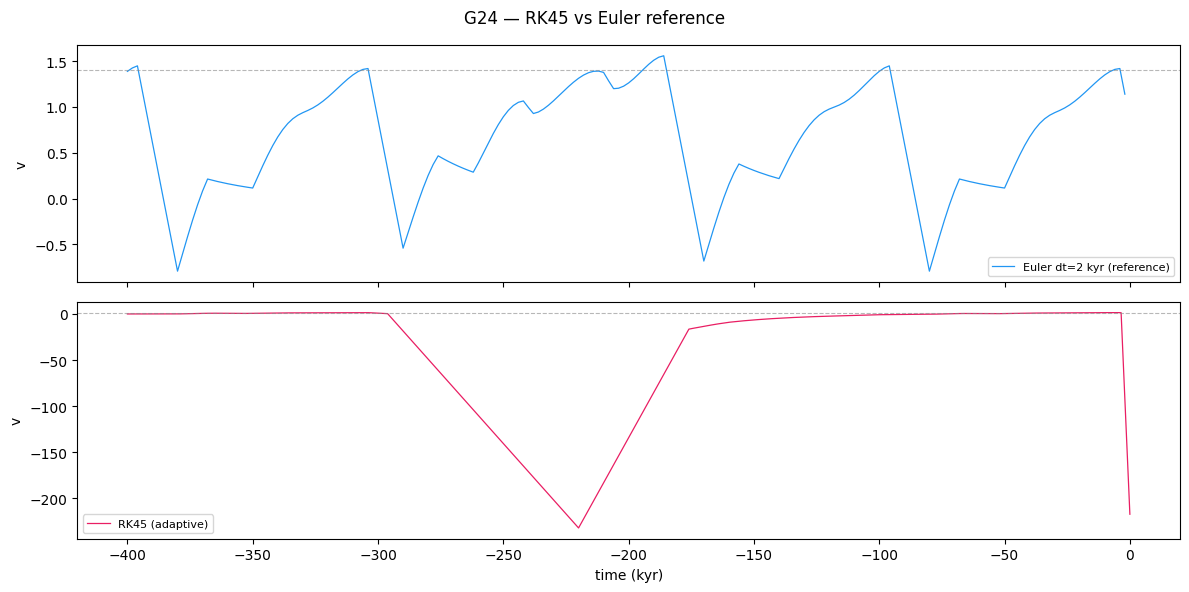

In [46]:
# Attempt RK45 — adaptive solver on a discontinuous RHS
try:
    m_rk45 = Model3(vc=vc, f1=f1, f2=f2, t1=t1, t2=t2)
    m_rk45.register_forcing('insolation', g24_forcing)
    out_rk45 = m_rk45.integrate(t_span=(-400, 0), y0=[0.0, 1], method='RK45')
    v_rk45 = out_rk45.state_variables['v']
    t_rk45 = out_rk45.time

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ref = runs_euler[2.0]
    mask = (ref.time >= -400) & (ref.time <= 0)
    axes[0].plot(ref.time[mask], ref.state_variables['v'][mask],
                 color='#2196F3', lw=0.9, label='Euler dt=2 kyr (reference)')
    axes[0].axhline(vc, ls='--', color='#888', lw=0.8, alpha=0.6)
    axes[0].set_ylabel('v'); axes[0].legend(fontsize=8); axes[0].invert_xaxis()

    axes[1].plot(t_rk45, v_rk45, color='#E91E63', lw=0.9, label='RK45 (adaptive)')
    axes[1].axhline(vc, ls='--', color='#888', lw=0.8, alpha=0.6)
    axes[1].set_ylabel('v'); axes[1].set_xlabel('time (kyr)')
    axes[1].legend(fontsize=8); axes[1].invert_xaxis()

    fig.suptitle('G24 — RK45 vs Euler reference')
    plt.tight_layout(); plt.show()

except Exception as e:
    print(f'RK45 failed: {type(e).__name__}: {e}')
    print()
    print('This is expected: Model3 has a discontinuous RHS (k switches at ')
    print('threshold crossings). Adaptive solvers like RK45 try to evaluate ')
    print('the derivative at intermediate sub-steps, and the threshold-crossing ')
    print('logic misfires there, causing the solver to either diverge, stall, ')
    print('or produce nonsense. Always use a fixed-step method with G24.')


**Note.** RK45 either fails outright or produces a qualitatively wrong
ice-volume record for G24.  The root cause is that `Model3` evaluates a
threshold (`v ≥ v_c` and `f ≥ f2`) at every derivative call — but RK45
evaluates the derivative at several internal sub-step times per step.  A
threshold crossing that occurs between two full steps triggers mid-stage,
leaving the model in the wrong regime for the remainder of the step.
Fixed-step solvers (`euler`, `rk4`) evaluate the derivative exactly once
per step, so threshold logic fires at the correct time.


## Lorenz96: stiff fast-slow system

The two-scale Lorenz96 model (`J > 0`) couples slow atmospheric variables
$X_k$ to $J$ fast variables $Y_{k,j}$.  The fast variables evolve on
timescales ~10× shorter than the slow ones, making the system mildly stiff.

**Adaptive solvers fail here.**  Scipy's RK45 evaluates `dydt` at
sub-step quadrature points to estimate local error.  For a model that
*accumulates state history* during `dydt` (as L96 does for its Y-variable
bookkeeping), those sub-step evaluations corrupt the history array and produce
a trajectory that is physically wrong — not just inaccurate, but completely
different from the true solution.

Use `method='rk4'` with an explicit fixed `dt ≤ 0.005`.

> *This example also appears in the `lorenz96` model demo, where it is
presented in the context of the full model walkthrough.  It is reproduced here
for thematic completeness.*


In [47]:
K, J_val = 36, 10
F_ts     = 10.0
rng      = np.random.default_rng(42)

y0 = np.concatenate([rng.standard_normal(K) + F_ts,
                     rng.standard_normal(K * J_val) * 0.01])

# Correct: rk4 with explicit dt and si
model_rk4 = Lorenz96(n=K, F=F_ts, J=J_val, h=1.0, b=10.0, c=10.0)
out_rk4   = model_rk4.integrate(
    t_span=(0, 10), y0=y0.tolist(), method='rk4',
    dt=0.005, kwargs={'si': 0.005}
)

# Wrong: RK45 adaptive — sub-step evaluations corrupt Y history
try:
    model_rk45 = Lorenz96(n=K, F=F_ts, J=J_val, h=1.0, b=10.0, c=10.0)
    out_rk45   = model_rk45.integrate(
        t_span=(0, 10), y0=y0.tolist(), method='RK45'
    )
    rk45_ok = True
except Exception as e:
    print(f'RK45 raised: {e}')
    rk45_ok = False


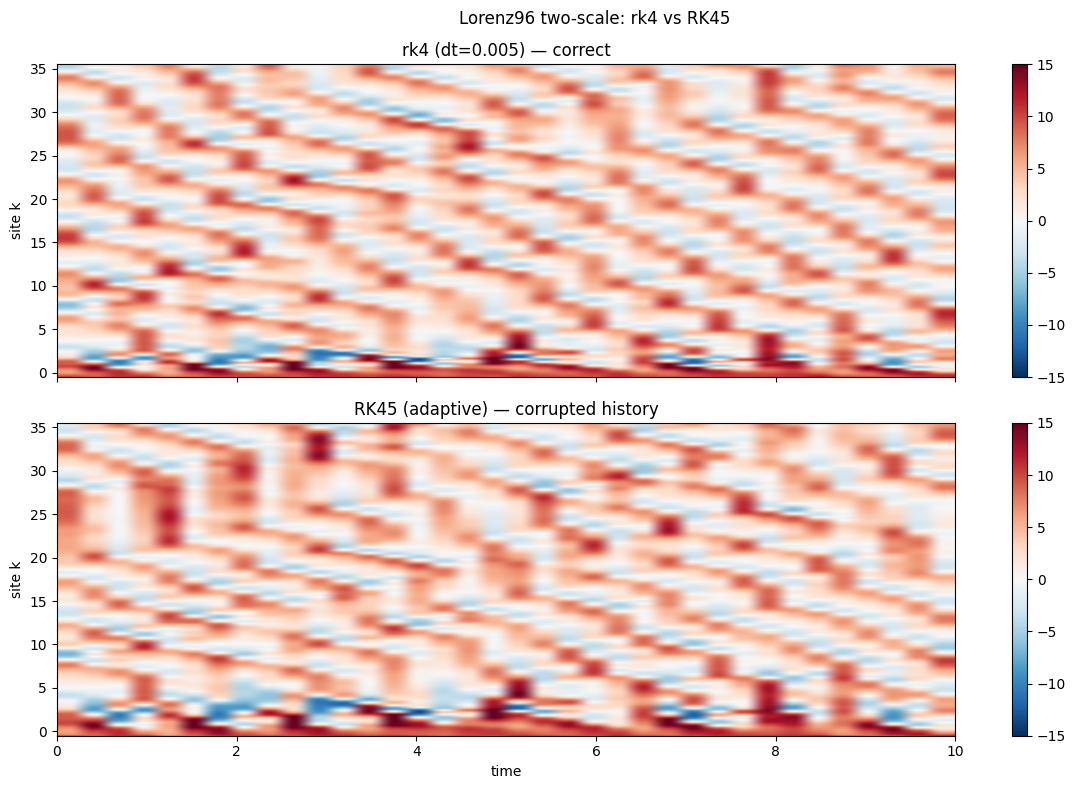

In [48]:
X_rk4 = np.array([out_rk4.state_variables[f'x{k}'] for k in range(K)])
t_rk4 = out_rk4.time

fig, axes = plt.subplots(1 + rk45_ok, 1, figsize=(12, 5 if not rk45_ok else 8),
                         sharex=True if rk45_ok else False)

if not rk45_ok:
    axes = [axes]

im0 = axes[0].imshow(X_rk4.T, aspect='auto', origin='lower',
                     extent=[t_rk4[0], t_rk4[-1], -0.5, K - 0.5],
                     cmap='RdBu_r', vmin=-15, vmax=15)
plt.colorbar(im0, ax=axes[0])
axes[0].set_ylabel('site k'); axes[0].set_title('rk4 (dt=0.005) — correct')

if rk45_ok:
    X_rk45 = np.array([out_rk45.state_variables[f'x{k}'] for k in range(K)])
    t_rk45 = out_rk45.time
    im1 = axes[1].imshow(X_rk45.T, aspect='auto', origin='lower',
                         extent=[t_rk45[0], t_rk45[-1], -0.5, K - 0.5],
                         cmap='RdBu_r', vmin=-15, vmax=15)
    plt.colorbar(im1, ax=axes[1])
    axes[1].set_ylabel('site k'); axes[1].set_title('RK45 (adaptive) — corrupted history')
    axes[-1].set_xlabel('time')
else:
    axes[0].set_xlabel('time')

fig.suptitle('Lorenz96 two-scale: rk4 vs RK45')
plt.tight_layout(); plt.show()


**Figure.** Space-time diagram of slow variable $X_k$ for the two-scale system.
The `rk4` run (top) shows the correct pattern: eastward-propagating wave packets
breaking into chaotic bursts, identical to the single-scale system at qualitative
level.  If RK45 does not crash (whether it crashes depends on the implementation
version), its output shows either explosive growth or spurious spatial patterns
— artefacts of corrupted sub-step Y-variable history.  Even when the error is
silent, the trajectory diverges from truth within a few time units.


## Summary: solver selection guide

| Model class | Recommended | Avoid | Key constraint |
|---|---|---|---|
| Smooth ODE (EBM0D, Stommel, ENSORecharge, Rössler, Lorenz63) | `RK45` (default) | `euler` unless timestep-matched | Use PB tight tolerances |
| Discrete-event ODE (G24) | `euler`, dt ≤ 6.5 kyr | `RK45`, `heun_maruyama` | Threshold crossings mis-stepped by adaptive solvers |
| Single-scale Lorenz96 | `RK45` or `rk4` | — | `dt=0.05` adequate for space-time diagnostics |
| Two-scale Lorenz96 | `rk4`, dt ≤ 0.005 | `RK45` (corrupts Y history) | `si` (recording interval) set equal to `dt` |
| DampedSpring / SimplePendulum | `RK45` | `euler` | Stiff regimes need tight rtol |
| DoublePendulum (energy diagnostics) | `RK45` with rtol ≤ 1e-8 | Default tolerances | Energy error scales with rtol |
| SDE models | `euler_maruyama`, `heun_maruyama`, or `milstein` | `RK45` | Must supply `sde_noise`; pass `random_seed` for reproducibility |
